# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [4]:
from astropy import units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [12]:
speed = 60 * u.kilometer / u.hour
new_speed = speed.to(u.meter / u.second)
print(f'{new_speed:.2f}')

16.67 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

In [ ]:
# A Julian Date is how many days an event takes place after noon, january 1st, 4713 BC

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

In [ ]:
# gregorian calendar is shorter and the julain calendar

From the astropy module `time` import `Time` in the cell below.

In [5]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [11]:
now = Time.now()
print(now)

2025-02-26 05:29:26.452375


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [17]:
time = Time("1969-07-02 20:17:00")
print(time)
print(time.jd)

1969-07-02 20:17:00.000
2440405.345138889


What historically happened at this date and time?

In [18]:
# The moon landing!

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [6]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [27]:
ra = 15 * u.degree
dec = -20 * u.degree
frame = 'icrs'

Convert the object's coordinates from ICSRS to **Galactic**.

In [28]:
target_icrs = SkyCoord(ra = ra, dec = dec, frame = frame)
print(target_icrs)

target_galactic = target_icrs.transform_to(Galactic())
print(target_galactic)

<SkyCoord (ICRS): (ra, dec) in deg
    (15., -20.)>
<SkyCoord (Galactic): (l, b) in deg
    (138.76123783, -82.60718782)>


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [38]:
# Define the location (Campbell Hall, UC Berkeley)
campbell_hall = EarthLocation.from_geodetic(lon = -122.257167 * u.deg, lat = 37.873250 * u.deg)

# Define the observation time (UTC)
observation_time = Time.now()

altaz_frame = AltAz(obstime=observation_time, location=campbell_hall)

# Transform to AltAz
object_altaz = object_icrs.transform_to(altaz_frame)
print(object_altaz)

<SkyCoord (AltAz: obstime=2025-02-26 06:04:28.962874, location=(-2690525.98107279, -4263043.88692398, 3894348.14832076) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (265.36469114, -27.47550963)>


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [7]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [8]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [9]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [43]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [49]:
# Open the fits file
with fits.open(image_file) as hdul:
    hdul.info()
    data = hdul[0].data # Getting primary information
    header = hdul[0].header # Getting header information

Filename: C:\Users\mmaga\.astropy\cache\download\url\ff6e0b93871033c68022ca026a956d87\contents
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     161   (891, 893)   int16   
  1  er.mask       1 TableHDU        25   1600R x 4C   [F6.2, F6.2, F6.2, F6.2]   


With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [52]:
# Find the brightest pixel value
brightest_pixel = np.max(data)

# Print the value of the brightest pixel
print(f"The brightest pixel value is: {brightest_pixel}")

The brightest pixel value is: 22918


With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [54]:
dimmest_pixel = np.min(data)
print(f'the dimmest pixel value is: {dimmest_pixel}')

the dimmest pixel value is: 3759


## Tables
From the astropy module `astropy.table` import `Table`.

In [10]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [66]:
star_data = {
    "name": ["pistol star", "barnard's star", "vy canis majoris"],
    "magnitude": [-10.75, 13.2, -0.67],
    "spectral type": ["LBV", "M4V", "M5C"]
}
table_of_stars = Table(star_data)
print(table_of_stars)

      name       magnitude spectral type
---------------- --------- -------------
     pistol star    -10.75           LBV
  barnard's star      13.2           M4V
vy canis majoris     -0.67           M5C


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [68]:
table_of_stars.write('stars_tables.fits', format='fits')

Read and print the table in the cell below from the `.fits` file you made.

In [69]:
# Read the table from the FITS file
table_from_fits = Table.read('stars_tables.fits', format='fits')

# Print the table
print(table_from_fits)

      name       magnitude spectral type
---------------- --------- -------------
     pistol star    -10.75           LBV
  barnard's star      13.2           M4V
vy canis majoris     -0.67           M5C


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

In [70]:
# HR Diagram is a graphical representation of how a star’s luminosity correlates with its temperature.
# also called a temperature-luminosity diagram

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [11]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [12]:
filename = 'cluster_data.tsv'
df = pd.read_table(filename, skiprows=44, sep=';', header=None, index_col=0,
                   names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType'],
                   skipfooter=1, engine='python')

Display the first few rows of the data.

In [14]:
print(df.head())  # Display first 5 rows

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [15]:
df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

C:\Users\mmaga\AppData\Local\Temp\ipykernel_21920\395354793.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)


Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [16]:
# Drop rows with NaN values
df_cleaned = df.dropna()

# Display first few rows of the cleaned data
print(df_cleaned.head())

      Vmag      Plx     B-V SpType
HIP                               
10    8.59    10.76   0.489    F6V
11    7.34     4.29   0.081     A2
12    8.43     4.06   1.484  K4III
13    8.80     3.49   1.128  K0III
14    7.25     5.11   1.200     K0


Run the cell below. We are converting the datatypes in the columns to floats.

In [17]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  118208.000000  117946.000000  116928.000000
mean        8.373183       7.215046       0.706391
std         1.312023      11.286330       0.489828
min        -1.440000     -54.950000      -0.400000
25%         7.640000       2.510000       0.347000
50%         8.440000       4.610000       0.612000
75%         9.150000       8.410000       1.078000
max        14.080000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [18]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


C:\Users\mmaga\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\mmaga\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

In [19]:
# it determines the absolute magnitude of stars, which is their true brightness if placed 10 parsecs away from earth

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [27]:
# MY CODE - your code gave me an error brianna so i rewrote it and fixed it a little bit
df_clean = df_clean.dropna(subset=['SpType'])

# Extract the first two characters)
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].notna() & df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'F1' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8'
 'M7' 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

In [28]:
# Hottest Stars → O-type stars
# Coldest Stars → M-type stars

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [29]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [30]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

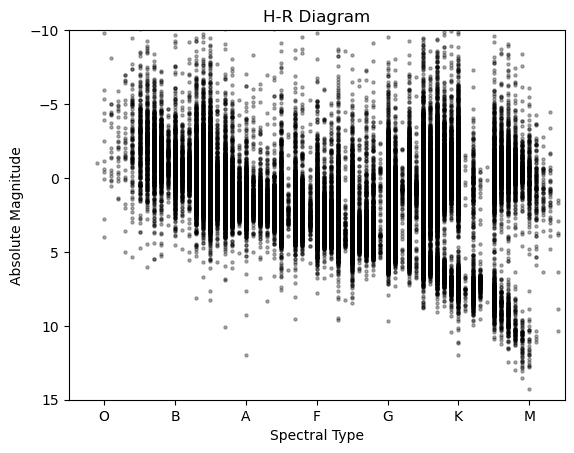

In [32]:
# Scatter plot with specified arguments
plt.scatter(df_clean['SpType2_numeric'], df_clean['M_V'], s=5, alpha=0.3, c='k')

# Set x and y limits
plt.xlim(0, 70)
plt.ylim(15, -10)  # Reverse y-axis as brighter stars have lower magnitude

# Set x-ticks and labels
plt.xticks(range(5, 75, 10), ['O', 'B', 'A', 'F', 'G', 'K', 'M'])

# Labels and title
plt.xlabel('Spectral Type')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram')

# Show the plot
plt.show()

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

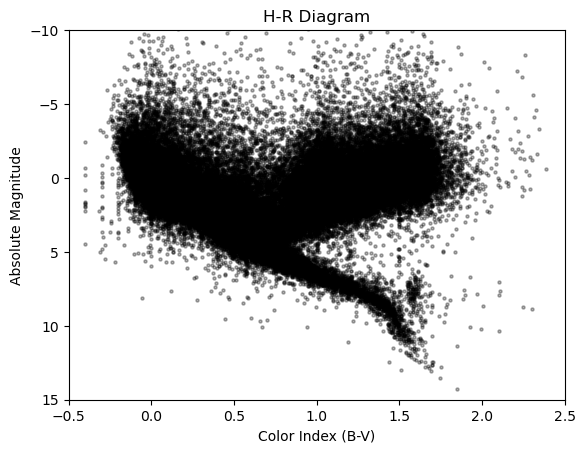

In [34]:
# Scatter plot with specified arguments
plt.scatter(df_clean['B-V'], df_clean['M_V'], s=5, alpha=0.3, c='k')

# Set x and y limits
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)  # Reverse y-axis as brighter stars have lower magnitude

# Labels and title
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram')

# Show the plot
plt.show()

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

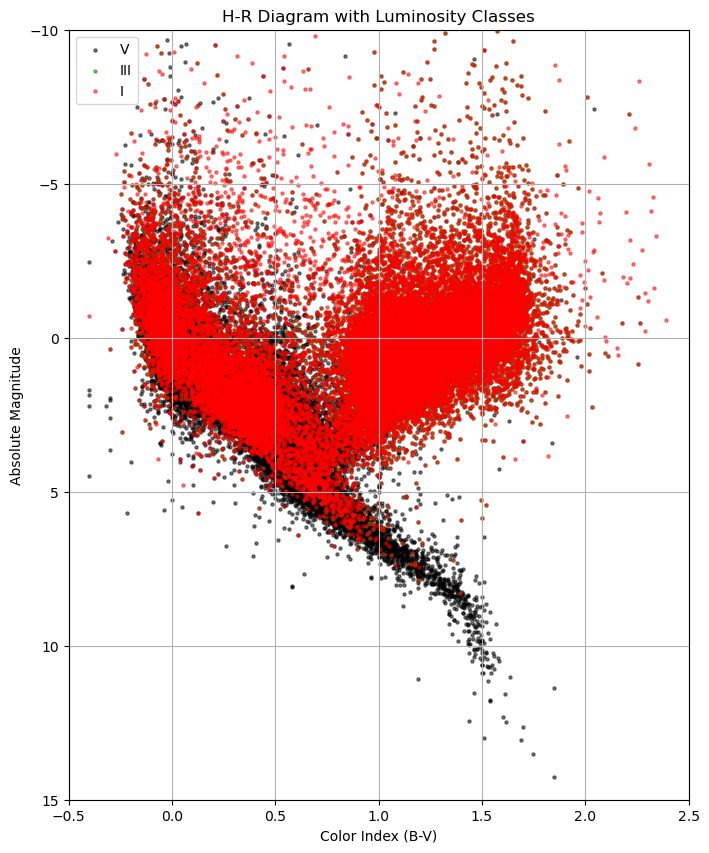

In [35]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()


With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

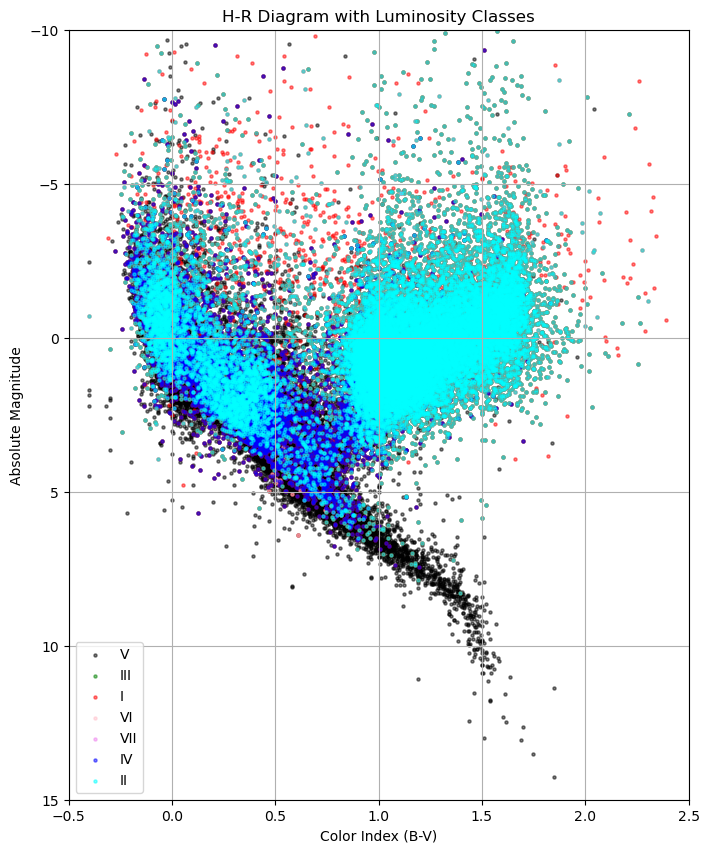

In [43]:
# With the ones above
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

# Plot previous types
plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

# Plot new types
plot_luminosity_class(df_clean, 'VI', 'pink')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'violet')  # White Dwarfs
plot_luminosity_class(df_clean, 'IV', 'blue')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'cyan')  # Bright Giants

plt.legend()
plt.show()

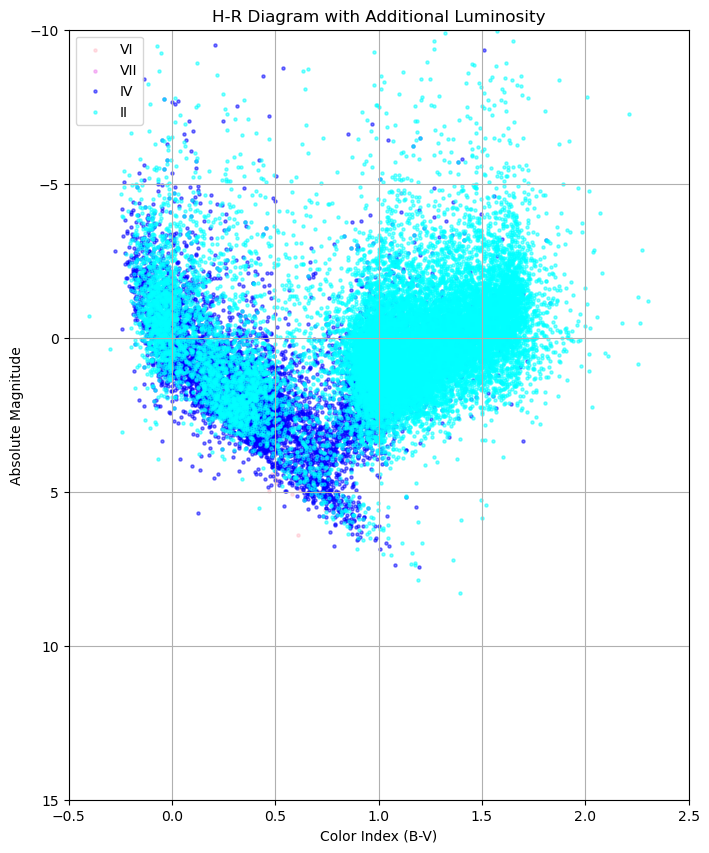

In [44]:
# Without the ones above
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Additional Luminosity')

# Plot only new types
plot_luminosity_class(df_clean, 'VI', 'pink')  # Subdwarfs
plot_luminosity_class(df_clean, 'VII', 'violet')  # White Dwarfs
plot_luminosity_class(df_clean, 'IV', 'blue')  # Subgiants
plot_luminosity_class(df_clean, 'II', 'cyan')  # Bright Giants

plt.legend()
plt.show()

Submit your FITS file and this notebook to Gradescope!